YFINANCE is already installed

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
auto_stocks = ["TM", "TSLA", "HMC", "F", "GM"]

raw_data = yf.download(auto_stocks, start="2021-01-01", end="2026-01-01")
close_prices = raw_data['Close']
close_prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,F,GM,HMC,TM,TSLA
Date,,,,,
2021-01-04,6.315689,38.908676,23.607718,135.069336,243.256668
2021-01-05,6.412055,40.013222,23.471653,135.166229,245.036667
2021-01-06,6.552897,41.281048,24.015923,135.280792,251.993332
2021-01-07,6.715979,41.607605,23.956392,134.523041,272.013336
2021-01-08,6.671503,41.357883,23.964895,134.681625,293.339996


calculating daily percentage changes (needed for histogram)

In [3]:
daily_returns = close_prices.pct_change()
volume = raw_data['Volume']

close_prices.head()

Ticker,F,GM,HMC,TM,TSLA
Date,,,,,
2021-01-04,6.315689,38.908676,23.607718,135.069336,243.256668
2021-01-05,6.412055,40.013222,23.471653,135.166229,245.036667
2021-01-06,6.552897,41.281048,24.015923,135.280792,251.993332
2021-01-07,6.715979,41.607605,23.956392,134.523041,272.013336
2021-01-08,6.671503,41.357883,23.964895,134.681625,293.339996


CALCULATING CUMULATIVE RETURNS
 (total growth , used to plot historical performance line)

In [4]:
tsla_cum = (1 + daily_returns['TSLA']).cumprod()
tm_cum = (1 + daily_returns['TM']).cumprod()
hmc_cum = (1 + daily_returns['HMC']).cumprod()
f_cum = (1 + daily_returns['F']).cumprod()
gm_cum = (1 + daily_returns['GM']).cumprod()

print("cumulative returns calculated")

cumulative returns calculated


now we will calculate 50 days simple moving average

In [5]:
ma50_df = close_prices.rolling(window=50).mean()
print("moving averages calculated")

moving averages calculated


Finding overall best and worst performing stock

In [6]:
tsla_growth = ((close_prices['TSLA'].iloc[-1]-close_prices['TSLA'].iloc[0])/close_prices['TSLA'].iloc[0])*100
tm_growth = ((close_prices['TM'].iloc[-1]-close_prices['TM'].iloc[0])/close_prices['TM'].iloc[0])*100
hmc_growth = ((close_prices['HMC'].iloc[-1]-close_prices['HMC'].iloc[0])/close_prices['HMC'].iloc[0])*100
f_growth = ((close_prices['F'].iloc[-1]-close_prices['F'].iloc[0])/close_prices['F'].iloc[0])*100
gm_growth = ((close_prices['GM'].iloc[-1]-close_prices['GM'].iloc[0])/close_prices['GM'].iloc[0])*100

print("TOTAL GROWTH OF THESE LISTED STOCKS OVER THE 5 YEARS ARE:")
print(f"TESLA (TSLA) Growth      : {tsla_growth:.2f}%")
print(f"TOYOTA (TM) Growth       : {tm_growth:.2f}%")
print(f"HONDA (HMC) Growth       : {hmc_growth:.2f}%")
print(f"FORD (F) Growth          : {f_growth:.2f}%")
print(f"GEN MOTORS (GM) Growth   : {gm_growth:.2f}%")

TOTAL GROWTH OF THESE LISTED STOCKS OVER THE 5 YEARS ARE:
TESLA (TSLA) Growth      : 84.87%
TOYOTA (TM) Growth       : 58.48%
HONDA (HMC) Growth       : 24.87%
FORD (F) Growth          : 102.95%
GEN MOTORS (GM) Growth   : 108.06%


SO, GEN MOTORS(GM) HAS THE HIGHEST GROWTH RATE AND
   HONDA (HMC) HAS THE LOWEST GROWTH RATE

ROLLING STANDARD DEVIATION
(measures the mathematical variance of daily returns)

In [7]:
tsla_vol = daily_returns['TSLA'].rolling(window=21).std()
tm_vol = daily_returns['TM'].rolling(window=21).std()
hmc_vol = daily_returns['HMC'].rolling(window=21).std()
f_vol = daily_returns['F'].rolling(window=21).std()
gm_vol = daily_returns['GM'].rolling(window=21).std()

print("rolling volatility calculated")

rolling volatility calculated


NOW , We will calculate maximum drawdown (worst-case risk)
this tracks how far each stock crashed from its highest peak before recovering

In [8]:
#Tesla
tsla_peak = close_prices['TSLA'].cummax()
tsla_dd = ((close_prices['TSLA']-tsla_peak)/tsla_peak).min()*100

#Toyota
tm_peak = close_prices['TM'].cummax()
tm_dd = ((close_prices['TM']-tm_peak)/tm_peak).min()*100

#Honda
hmc_peak = close_prices['HMC'].cummax()
hmc_dd = ((close_prices['HMC']-hmc_peak)/hmc_peak).min()*100

#Ford
f_peak = close_prices['F'].cummax()
f_dd = ((close_prices['F']-f_peak)/f_peak).min()*100

#Gen motors
gm_peak = close_prices['GM'].cummax()
gm_dd = ((close_prices["GM"]-gm_peak)/gm_peak).min()*100

print("WORST CASE HISTORICAL CRASHING POINT")
print(f"Tesla max crash         : {tsla_dd:.2f}%")
print(f"Toyota max crash        : {tm_dd:.2f}%")
print(f"Honda max crash         : {hmc_dd:.2f}%")
print(f"Ford max crash          : {f_dd:.2f}%")
print(f"General Motrs max crash : {gm_dd:.2f}%")

WORST CASE HISTORICAL CRASHING POINT
Tesla max crash         : -73.63%
Toyota max crash        : -36.80%
Honda max crash         : -35.20%
Ford max crash          : -56.51%
General Motrs max crash : -58.96%


HISTOGRAM

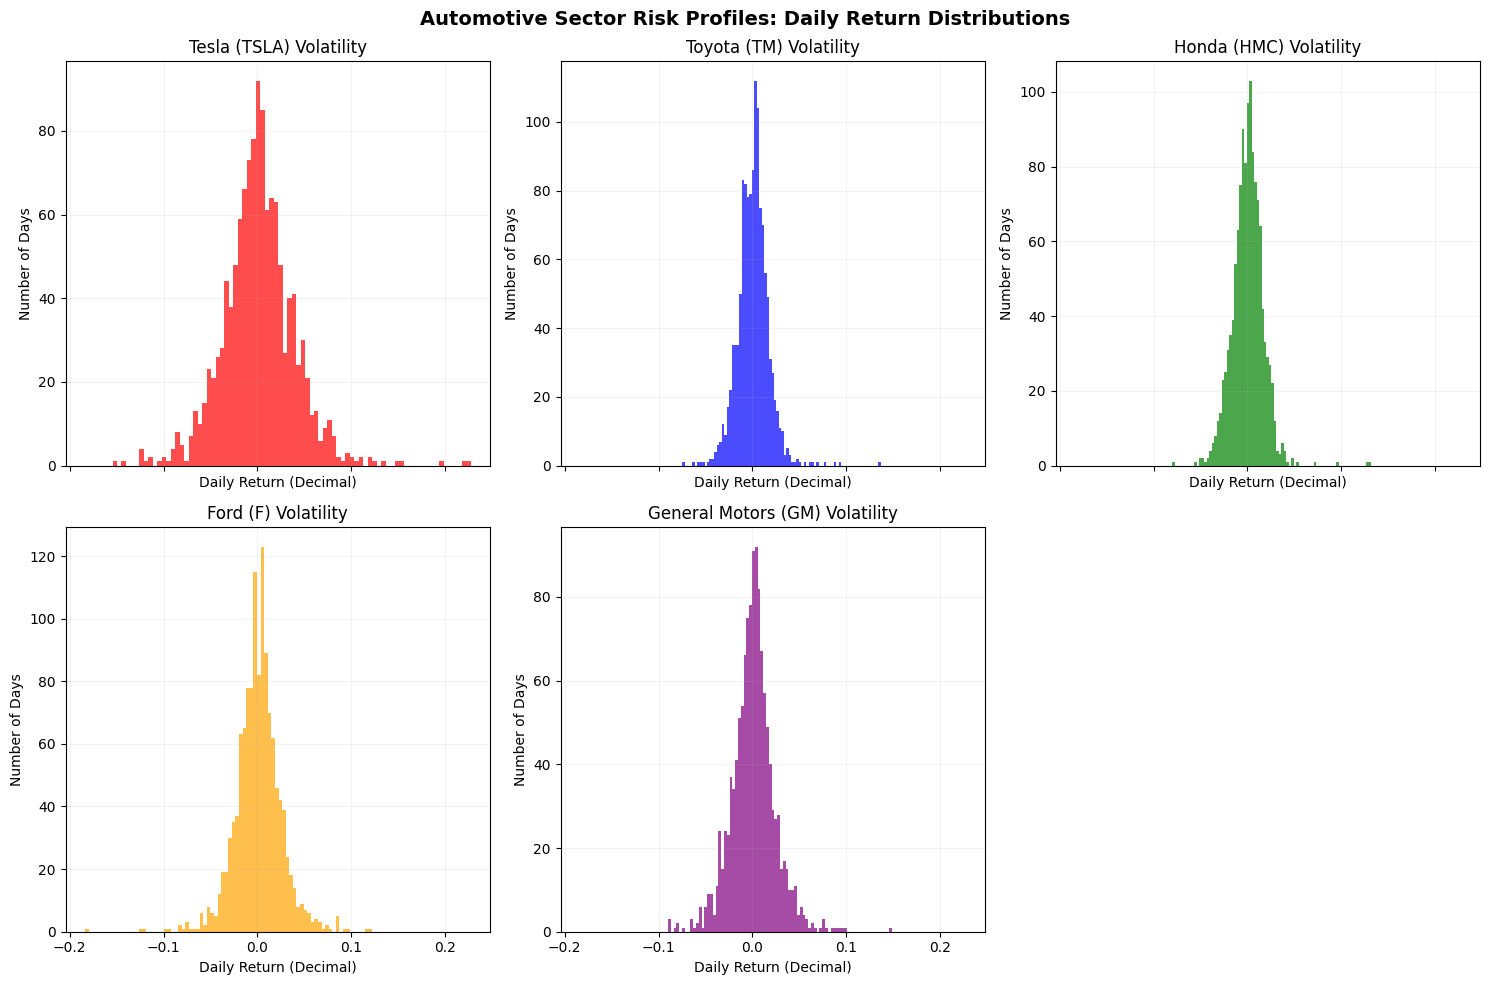

In [9]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True)

axes[0, 0].hist(daily_returns['TSLA'].dropna(), bins=80, color='red', alpha=0.7)
axes[0, 0].set_title("Tesla (TSLA) Volatility")
axes[0, 0].grid(True, alpha=0.15)

axes[0, 1].hist(daily_returns['TM'].dropna(), bins=80, color='blue', alpha=0.7)
axes[0, 1].set_title("Toyota (TM) Volatility")
axes[0, 1].grid(True, alpha=0.15)

axes[0, 2].hist(daily_returns['HMC'].dropna(), bins=80, color='green', alpha=0.7)
axes[0, 2].set_title("Honda (HMC) Volatility")
axes[0, 2].grid(True, alpha=0.15)

axes[1, 0].hist(daily_returns['F'].dropna(), bins=80, color='orange', alpha=0.7)
axes[1, 0].set_title("Ford (F) Volatility")
axes[1, 0].grid(True, alpha=0.15)

axes[1, 1].hist(daily_returns['GM'].dropna(), bins=80, color='purple', alpha=0.7)
axes[1, 1].set_title("General Motors (GM) Volatility")
axes[1, 1].grid(True, alpha=0.15)


axes[1, 2].axis('off')

fig.suptitle("Automotive Sector Risk Profiles: Daily Return Distributions", fontsize=14, fontweight='bold')
for ax in axes.flat:
    ax.set_xlabel("Daily Return (Decimal)")
    ax.set_ylabel("Number of Days")

plt.tight_layout()
plt.show()

VOLUME ANALYSIS

In [10]:
tsla_avg_vol = volume['TSLA'].mean()
tm_avg_vol = volume['TM'].mean()
hmc_avg_vol = volume['HMC'].mean()
f_avg_vol = volume['F'].mean()
gm_avg_vol = volume['GM'].mean()

print("Average daily trading volume of the listed stocks are :")
print(f"Tesla average volume   : {tsla_avg_vol:,.0f}")
print(f"Toyota average volume  : {tm_avg_vol:,.0f}")
print(f"Honda average volume   : {hmc_avg_vol:,.0f}")
print(f"Ford average volume    : {f_avg_vol:,.0f}")
print(f"GM average volume      : {gm_avg_vol:,.0f}")

Average daily trading volume of the listed stocks are :
Tesla average volume   : 99,753,536
Toyota average volume  : 305,723
Honda average volume   : 1,026,446
Ford average volume    : 70,986,510
GM average volume      : 15,291,579
